# Calculating the Internal Froud Number

<span style="color:red">This code was last tested on February 24, 2026, and is running without issues.</span>


**PURPOSE:** After Running the STEP1, 2 and 3 you can run this code to calculate the Internal Froud Number 

__________________________________________________________________________________________  

**Input files:**  

   
matrix_alltogether.pkl  
Rotated_velocity.pkl  


on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/MCTD_profiles_data/"

**Output files:** 

junta_pic_Fr.pkl  
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_dir/processed_data/" 


  
Froud_X_Pycnocline.png  
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_dir/processed_image/"  
__________________________________________________________________________________________

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm # Imports colormaps
import os

In [2]:
output_data = '../output_dir/processed_data/'
output_image = '../output_dir/processed_image/'

os.makedirs(output_data, exist_ok=True)
os.makedirs(output_image, exist_ok=True)

In [3]:
with open(output_data + 'matrix_alltogether.pkl','rb') as io:
    mtz_tj = pickle.load(io)

In [4]:
# defining variables:

rho_x = mtz_tj[:,1]
rho_z = mtz_tj[:,2]
rho = mtz_tj[:,5]

In [5]:
# junta = [x, z, vr]
# junta_veloc = [x, z, vr, ur]
with open(output_data + 'Rotated_velocity.pkl', 'rb') as io:
    m_corr = pickle.load(io)

corr_x = m_corr[0]
corr_z = m_corr[1]
corr_long = m_corr[2]

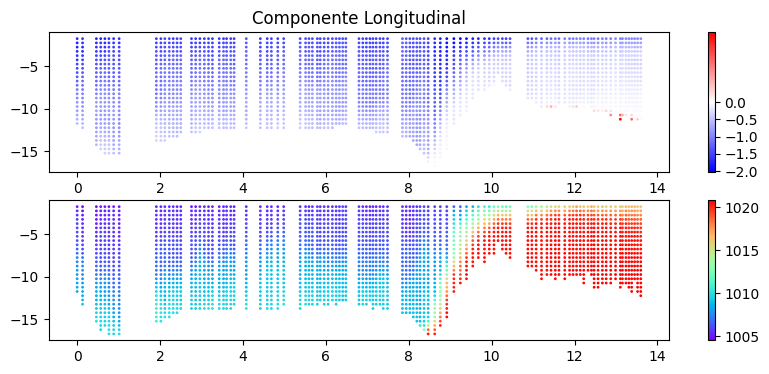

In [6]:
fig, axs = plt.subplots(2, figsize=(10,4))

norm_long = mcolors.TwoSlopeNorm(vmin=np.nanmin(corr_long), vmax=np.nanmax(corr_long), vcenter=0)
cb1 = axs[0].scatter(corr_x, -corr_z, 1, c=corr_long, cmap='bwr', norm=norm_long)
axs[0].set_title('Componente Longitudinal')
fig.colorbar(cb1)

cb2 = axs[1].scatter(corr_x, -corr_z, 1, c=rho, cmap='rainbow')
fig.colorbar(cb2)

In [7]:
rho.shape

(2386,)

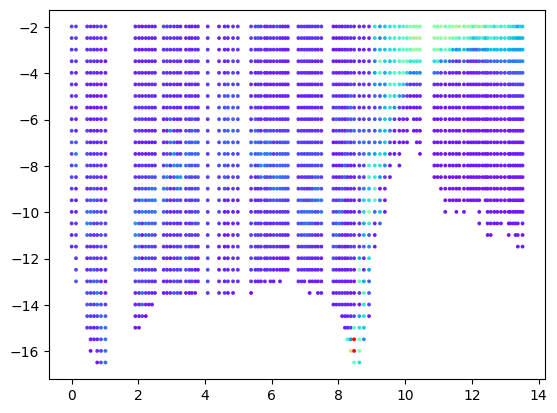

In [8]:
n_perfs = int(np.max(mtz_tj[:,0]))

dif_rho = []
dif_z = []
dif_x = []

for i in range(n_perfs):
   
    idx = np.where(mtz_tj[:,0] == i)[0]

    perfil = mtz_tj[idx, :]

    rho_p = perfil[:,5]
    z = -perfil[:,2]

    drho = np.diff(rho_p)
    novo_z = (z[1:] + z[:-1])/2
    novo_x = perfil[1:,1]

    dif_rho = dif_rho + drho.tolist()
    dif_z = dif_z + novo_z.tolist()
    dif_x = dif_x + novo_x.tolist()

dif_z = np.array(dif_z)
plt.scatter(dif_x, dif_z, 3, c=dif_rho, cmap='rainbow')
    

In [9]:
rho.shape

(2386,)

The pycnocline was calculated manually at the inflection of the plume 

In [10]:
# a partir do 65
#inflexao_pluma = [16, 14, 13, 10, 8]
# a partir do 65 (da Débora)
inflexao_pluma = [16, 14, 13, 10, 8, 7, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,4,4,4,  4, 4, 5, 5, 6,6, 6, 6, 7 ]

In [11]:
corr_z.shape

(2386,)

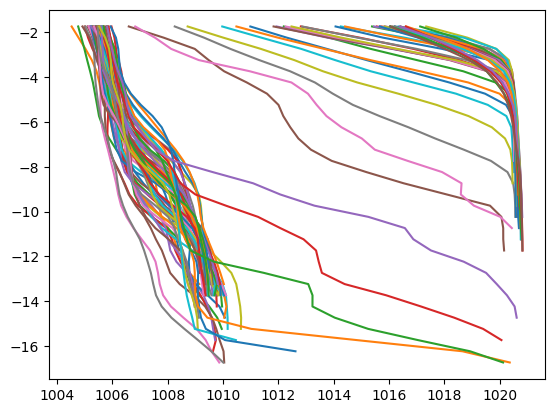

In [12]:
n_perfs = int(np.max(mtz_tj[:,0]))

dif_rho = []
dif_z = []
dif_x = []

for i in range(n_perfs):
   
    idx = np.where(mtz_tj[:,0] == i)[0]

    perfil = mtz_tj[idx, :]

    rho_p = perfil[:,5]
    z = -perfil[:,2]

    drho_dz = np.gradient(rho_p, z)

    idx_pic = np.argmax(np.abs(drho_dz)) -1
    z_pic = z[idx_pic]

    plt.plot(rho_p, z)
    

Reploting the above figure separating by color blue (inside breakwater) x red (outside breakwater) 

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_98167/952411163.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_azul = cm.get_cmap('Blues')
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_98167/952411163.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_vermelho = cm.get_cmap('Reds')


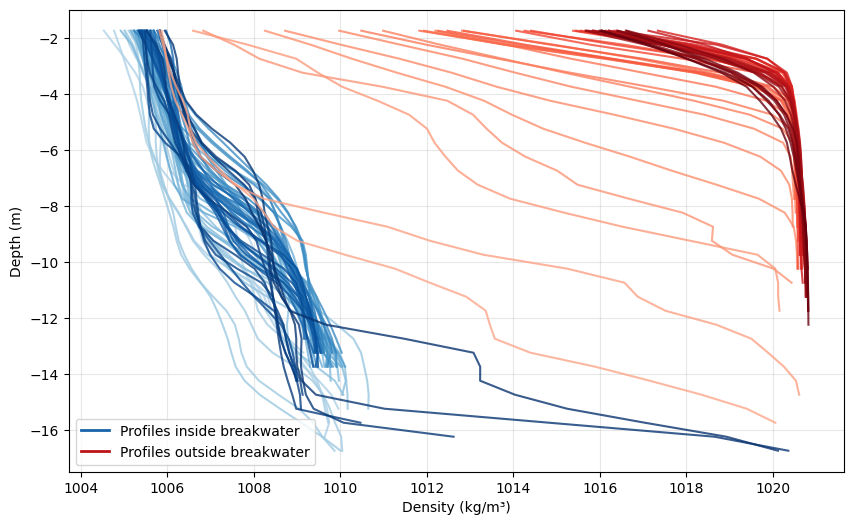

In [13]:
# Assumindo que mtz_tj está definido e carregado
# mtz_tj = ... 

# Garante que n_perfs seja o valor máximo do índice de perfil
n_perfs = int(np.nanmax(mtz_tj[:, 0]))

plt.figure(figsize=(10, 6))
#plt.title('Density Profiles Inside X Outside breakwater')
plt.xlabel('Density (kg/m³)')
plt.ylabel('Depth (m)')

# Definindo o índice de corte
INDICE_CORTE = 62

# Preparando os colormaps
cmap_azul = cm.get_cmap('Blues') 
cmap_vermelho = cm.get_cmap('Reds')

# Define os limites de normalização para cada grupo
n_azuis = INDICE_CORTE + 1  # 0 to 62 (63 profiles)
n_vermelhos = n_perfs - INDICE_CORTE

for i in range(n_perfs + 1): # +1 to include the last index
    
    idx = np.where(mtz_tj[:, 0] == i)[0]
    
    if len(idx) < 2:
        continue # Skip profiles with less than 2 points
        
    perfil = mtz_tj[idx, :]

    # Ensuring data is float for plotting
    rho_p = perfil[:, 5].astype(float)
    z = -perfil[:, 2].astype(float) # Z positive downward

    # === Color Selection Logic ===
    if i <= INDICE_CORTE:
        # Profiles up to 62 (inclusive): Shades of Blue
        # Normalize index i for the blue colormap
        norm_i = i / n_azuis
        cor = cmap_azul(0.3 + 0.7 * norm_i) # Starts at 0.3 to avoid near-white
        
    else:
        # Profiles after 62: Shades of Red
        # Normalize index i within the range of reds
        norm_i = (i - INDICE_CORTE) / n_vermelhos
        cor = cmap_vermelho(0.3 + 0.7 * norm_i) # Starts at 0.3 to avoid near-white
    
    # === Plotting ===
    plt.plot(rho_p, z, color=cor, linewidth=1.5, alpha=0.8)

# Invert Y-axis so depth increases downward
#plt.gca().invert_yaxis()

# Add simple legend for the groups (in English)
plt.plot([], [], color=cmap_azul(0.8), linewidth=2, label=f'Profiles inside breakwater')
plt.plot([], [], color=cmap_vermelho(0.8), linewidth=2, label=f'Profiles outside breakwater')

plt.legend ()#title="Profile Range"
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_image,'densityprofiles_insideXoutside.png'), dpi=300)
plt.show()

## Calculating the Barotropic Froude Number

In [14]:
# ============================
# 1) CALCULATING FROUDE NUMBER
# ============================
g = 9.81
min_pts_fundo = 3     # mínimo de pontos válidos de velocidade abaixo da interface
min_h2 = 0.5          # espessura mínima da camada de fundo (m) para calcular Fr
usar_interpolacao_u = False  # True: interpola u verticalmente dentro de cada perfil

perfis = np.unique(mtz_tj[:,0].astype(int))

guarda_Fr  = []
guarda_dist = []
guarda_pic = []
guarda_U1   = []   # upper-layer mean velocity
guarda_U2   = []   # lower-layer mean velocity
guarda_gred = []   # reduced gravity g'
guarda_h1   = []   # pycnocline depth from surface


for i in perfis:
    idx = np.where(mtz_tj[:,0].astype(int) == i)[0]
    if idx.size == 0:
        continue

    perfil = mtz_tj[idx, :]

    # ordena por profundidade
    z = perfil[:, 2].astype(float)
    ordz = np.argsort(z)
    z = z[ordz]
    densidade = perfil[ordz, 5].astype(float)

    # alinhar velocidade do mesmo perfil e ordenar pelo mesmo índice
    u_raw = corr_long[idx].astype(float)[ordz]

    # (opcional) interpolação vertical para preencher buracos internos de u
    if usar_interpolacao_u:
        ok = np.isfinite(u_raw)
        if ok.sum() >= 2:
            u = np.interp(z, z[ok], u_raw[ok])
        else:
            u = u_raw.copy()
    else:
        u = u_raw.copy()

    # escolhe posição da picnoclina
    drho = np.diff(densidade)
    if drho.size == 0 or np.all(~np.isfinite(drho)):
        # sem gradiente utilizável
        guarda_Fr.append(np.nan)
        guarda_dist.append(perfil[0,1])
        guarda_pic.append(np.nan)
        continue

    if i < 65:
        i_pic = int(np.nanargmax(drho))
    else:
        # usa vetor externo, mas mantém válido
        i_pic = int(np.clip(int(inflexao_pluma[i-65]), 0, len(z)-2))

    # garante faixa válida
    i_pic = int(np.clip(i_pic, 0, len(z)-2))

    # se o fundo fica muito fino ou sem dados, sobe a interface até atender critérios
    valid_u = np.isfinite(u)
    zmin, zmax = np.nanmin(z), np.nanmax(z)

    while True:
        # interface no meio dos dois níveis
        z_int = 0.5*(z[i_pic] + z[i_pic+1])
        h2 = zmax - z_int
        n_valid_fundo = int(np.sum(valid_u[i_pic+1:]))

        if (n_valid_fundo >= min_pts_fundo) and (h2 >= min_h2):
            break
        if i_pic == 0:
            break
        i_pic -= 1  # sobe 1 degrau

    # separa camadas
    topo_slice  = slice(0, i_pic+1)
    fundo_slice = slice(i_pic+1, None)

    # médias de u e rho usando apenas valores finitos
    U_topo_vals  = u[topo_slice]
    U_fundo_vals = u[fundo_slice]

    rho_top_vals  = densidade[topo_slice]
    rho_fundo_vals = densidade[fundo_slice]

    U_topo  = np.nanmean(U_topo_vals[np.isfinite(U_topo_vals)])
    U_fundo = np.nanmean(U_fundo_vals[np.isfinite(U_fundo_vals)])
    rho_top = np.nanmean(rho_top_vals[np.isfinite(rho_top_vals)])
    rho_fun = np.nanmean(rho_fundo_vals[np.isfinite(rho_fundo_vals)])

    # checagens mínimas
    if (not np.isfinite(U_topo)) or (not np.isfinite(U_fundo)) \
       or (not np.isfinite(rho_top)) or (not np.isfinite(rho_fun)) \
       or (rho_top == 0):
        Fr = np.nan
    else:
        g_red = g * (rho_fun - rho_top) / rho_top
        z_int = 0.5*(z[i_pic] + z[i_pic+1])
        h1 = z_int - zmin
        h2 = zmax - z_int

        if (g_red <= 0) or (h1 <= 0) or (h2 <= 0):
            Fr = np.nan
        else:
            c = np.sqrt(g_red * h1 * h2 / (h1 + h2))
            U_rel = abs(U_topo - U_fundo)
            Fr = U_rel / c if c > 0 else np.nan

    guarda_dist.append(perfil[0,1])
    guarda_pic.append(z_int)
    guarda_Fr.append(Fr)
    guarda_U1.append(U_topo if np.isfinite(U_topo) else np.nan)
    guarda_U2.append(U_fundo if np.isfinite(U_fundo) else np.nan)
    guarda_gred.append(g_red if 'g_red' in locals() and np.isfinite(g_red) else np.nan)
    guarda_h1.append(h1 if 'h1' in locals() and np.isfinite(h1) else np.nan)

guarda_dist = np.asarray(guarda_dist, float)
guarda_pic  = np.asarray(guarda_pic,  float)
guarda_Fr   = np.asarray(guarda_Fr,   float)



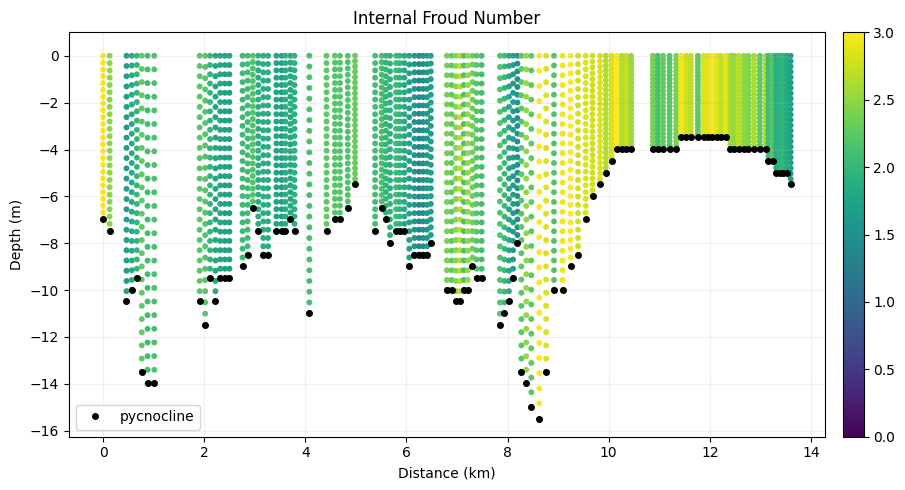

In [15]:
# vetores já calculados
dist = np.asarray(guarda_dist, float)      # distância (km)
Fr   = np.asarray(guarda_Fr,   float)      # froude por perfil
zpic = np.asarray(guarda_pic,  float)      # profundidade da picnoclina (m, positiva p/ baixo)

# filtra perfis válidos
mask = np.isfinite(dist) & np.isfinite(Fr) & np.isfinite(zpic) & (zpic > 0)
dist, Fr, zpic = dist[mask], Fr[mask], zpic[mask]

# --- monta as “colunas” (0 até picnoclina) ---
n_levels = 25   # nº de pontos verticais em cada coluna (ajuste à vontade)

Xs, Ys, Cs = [], [], []
for d, zp, fr in zip(dist, zpic, Fr):
    ycol = -np.linspace(0, zp, n_levels)          # 0 (superfície) até -zpic (profundidade)
    Xs.append(np.full(n_levels, d))
    Ys.append(ycol)
    Cs.append(np.full(n_levels, fr))

X = np.concatenate(Xs)
Y = np.concatenate(Ys)
C = np.concatenate(Cs)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 5))

# escala 0→vmax (ajuste o teto se quiser)
vmin, vmax = 0.0, max(3.0, np.nanpercentile(Fr, 95))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sc = ax.scatter(X, Y, c=C, cmap='viridis', norm=norm, s=18, edgecolors='none')
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('')

# picnoclina (pontos pretos)
ax.plot(dist, -zpic, 'ko', ms=4, label='pycnocline')

ax.set_title('Internal Froud Number')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Depth (m)')
ax.legend(loc='lower left')
ax.set_ylim(Y.min()*1.05, 1)   # deixa um respiro acima de 0
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


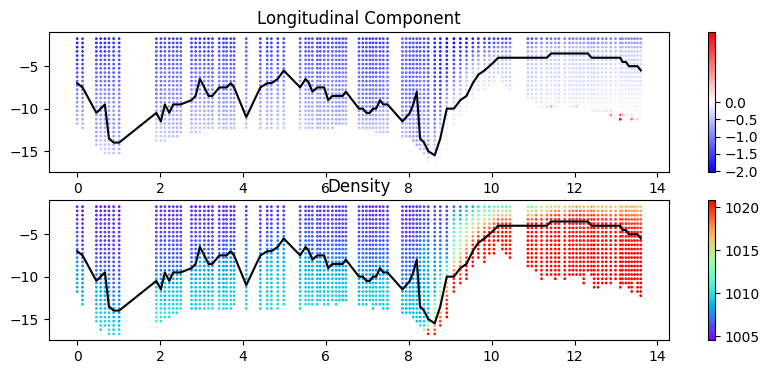

In [20]:
fig, axs = plt.subplots(2, figsize=(10,4))

norm_long = mcolors.TwoSlopeNorm(vmin=np.nanmin(corr_long), vmax=np.nanmax(corr_long), vcenter=0)
cb1 = axs[0].scatter(corr_x, -corr_z, 1, c=corr_long, cmap='bwr', norm=norm_long)
axs[0].set_title('Longitudinal Component')
fig.colorbar(cb1)

cb2 = axs[1].scatter(corr_x, -corr_z, 1, c=rho, cmap='rainbow')
axs[1].set_title('Density')

for ax in axs:
    ax.plot(guarda_dist, -np.array(guarda_pic), 'k')
fig.colorbar(cb2)

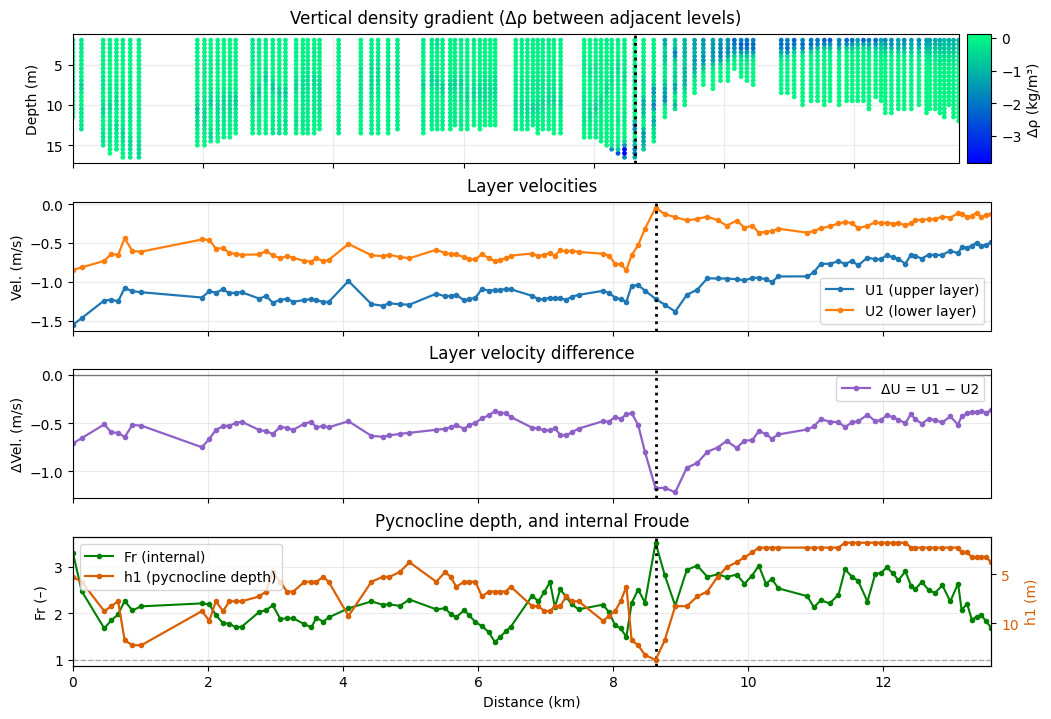

In [19]:
from mpl_toolkits.axes_grid1 import make_axes_locatable  # p/ colorbar ao lado do eixo

# ========= Δρ between adjacent levels =========
n_perfs = int(np.nanmax(mtz_tj[:, 0]))
dif_rho, dif_z, dif_x = [], [], []

for i in range(n_perfs + 1):  # include last index
    idx = np.where(mtz_tj[:, 0] == i)[0]
    if len(idx) < 2:
        continue

    perfil = mtz_tj[idx, :]
    rho_p   = perfil[:, 5].astype(float)
    z_depth = -perfil[:, 2].astype(float)   # depth positive downward
    x_prof  = perfil[:, 1].astype(float)

    ordz = np.argsort(z_depth)
    rho_p   = rho_p[ordz]
    z_depth = z_depth[ordz]
    x_prof  = x_prof[ordz]

    drho  = np.diff(rho_p)
    mid_z = (z_depth[1:] + z_depth[:-1]) / 2.0
    mid_x = x_prof[1:]

    dif_rho.extend(drho.tolist())
    dif_z.extend(mid_z.tolist())
    dif_x.extend(mid_x.tolist())

dif_rho = np.asarray(dif_rho, float)
dif_z   = np.asarray(dif_z,   float)
dif_x   = np.asarray(dif_x,   float)

# ========= Arrays from your Fr / layers calc =========
x   = np.asarray(guarda_dist, float)
U1  = np.asarray(guarda_U1,   float)   # upper-layer velocity
U2  = np.asarray(guarda_U2,   float)   # lower-layer velocity
dU  = U1 - U2                           # relative velocity
h1  = np.asarray(guarda_h1,   float)    # pycnocline depth (positive downward)

ok    = np.isfinite(x)
order = np.argsort(x[ok])
x   = x[ok][order]
U1  = U1[ok][order]
U2  = U2[ok][order]
dU  = dU[ok][order]
h1  = h1[ok][order]

Fr = np.asarray(guarda_Fr, float)
Fr = Fr[ok][order]

# ========= FIGURE (4 panels) =========
fig, axs = plt.subplots(4, 1, figsize=(11, 8.2), sharex=True)
# deixa uma folga sutil à direita; o cbar será anexado AO EIXO 1, sem encolhê-lo
plt.subplots_adjust(right=0.96, hspace=0.30)

# ---------- Panel 1: Δρ between levels (mais azul, cbar ao lado) ----------
sc = axs[0].scatter(dif_x, -dif_z, s=6, c=dif_rho, cmap='winter')
axs[0].invert_yaxis()  # ✅ profundidade cresce para baixo
axs[0].set_title('Vertical density gradient (Δρ between adjacent levels)', pad=8)
axs[0].set_ylabel('Depth (m)')
axs[0].grid(alpha=0.25)

# colorbar acoplada somente ao eixo do painel 1 (não afeta os demais)
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="2.8%", pad=0.08)  # largura e afastamento do cbar
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('Δρ (kg/m³)')

# ---------- Panel 2: layer velocities ----------
axs[1].plot(x, U1, '-o', ms=3, lw=1.6, label='U1 (upper layer)')
axs[1].plot(x, U2, '-o', ms=3, lw=1.6, label='U2 (lower layer)')
axs[1].set_title('Layer velocities', pad=8)
axs[1].set_ylabel('Vel. (m/s)')
axs[1].grid(alpha=0.25)
axs[1].legend()

# ---------- Panel 3: velocity difference ----------
axs[2].plot(x, dU, '-o', ms=3, lw=1.6, color='#8E61C7', label='ΔU = U1 − U2')
axs[2].axhline(0, color='k', lw=1, alpha=0.5)
axs[2].set_title('Layer velocity difference', pad=8)
axs[2].set_ylabel('ΔVel. (m/s)')
axs[2].grid(alpha=0.25)
axs[2].legend()

# ---------- Panel 4: h1 and internal Froude ----------
ax3 = axs[3]
ax3.set_title('Pycnocline depth, and internal Froude', pad=8)
ax3.plot(x, Fr, '-o', ms=3, lw=1.5, color='g', label='Fr (internal)')
ax3.axhline(1, color='gray', ls='--', lw=1, alpha=0.6)
ax3.set_ylabel('Fr (–)')
ax3.set_axisbelow(True)
ax3.grid(alpha=0.25)

ax3b = ax3.twinx()
ax3b.plot(x, h1, '-o', ms=3, lw=1.6, color='#D95F02', label='h1 (pycnocline depth)')
ax3b.set_ylabel('h1 (m)', color='#D95F02')
ax3b.tick_params(axis='y', labelcolor='#D95F02')
ax3b.invert_yaxis()

# legenda combinada
lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3b.legend(lines + lines2, labels + labels2, loc='upper left')

axs[3].set_xlabel('Distance (km)')

# ---------- alinhar X em todos os painéis ----------
xmin = np.nanmin([np.nanmin(x),  np.nanmin(dif_x)]) if dif_x.size else np.nanmin(x)
xmax = np.nanmax([np.nanmax(x),  np.nanmax(dif_x)]) if dif_x.size else np.nanmax(x)
for ax in axs:
    ax.set_xlim(xmin, xmax)

# ---------- jetties (molhes) vertical line em todos ----------
try:
    molhes_x = x[62]  # ajuste se necessário
    for ax in axs:
        ax.axvline(molhes_x, color='k', ls=':', lw=2)
except Exception:
    pass

plt.savefig(os.path.join(output_image,'Froud_X_Pycnocline.png'), dpi=300)
plt.show()


### Saving Froud Number and pycnocline pickle:

In [18]:
junta_picnoclina_Froude = [guarda_dist, Y, guarda_pic, guarda_Fr]



# Save the pickle on the right folder:
with open(os.path.join(output_data, 'junta_pic_Fr.pkl'), 'wb') as io:
        pickle.dump(junta_picnoclina_Froude, io)


<span style="color:red">This code was last tested on February 24, 2026, and is running without issues.</span>


## END OF CODE